In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from typing import Optional, Tuple, List

from itertools import combinations

# Код для общей ANOVA-kernel

In [50]:
# простой класс, не используем
class HOFM_Exact_simple(nn.Module):
    def __init__(self, n_features: int, order: int, n_factors: int):
        super().__init__()
        self.n_features = n_features
        self.order = order
        self.n_factors = n_factors

        self.w0 = nn.Parameter(torch.zeros(1))
        self.w = nn.Parameter(torch.zeros(n_features))
        self.V = nn.Parameter(torch.randn(n_features, n_factors) * 0.01)

    def forward(self, x: torch.Tensor, return_all: bool = False) -> Tuple[torch.Tensor, ...]:
        """
        Если return_all=False, возвращает f(x).
        Если return_all=True, возвращает (f(x), e1, e2, ..., e_order), где e_p
        — тензор формы (batch,) с вкладом порядка p (без w0 и линейной части).
        """
        batch_size = x.shape[0]
        device = x.device
        dtype = x.dtype

        # Линейная часть
        linear = self.w0 + torch.matmul(x, self.w)  # (batch,)

        # Инициализация e[p] для p=0..order
        e = [torch.ones(batch_size, self.n_factors, device=device, dtype=dtype)]  # e0
        for _ in range(1, self.order + 1):
            e.append(torch.zeros(batch_size, self.n_factors, device=device, dtype=dtype))

        # Обход всех признаков
        for i in range(self.n_features):
            xi = x[:, i].unsqueeze(1)               # (batch, 1)
            vi = self.V[i].unsqueeze(0)             # (1, n_factors)
            contrib = vi * xi                       # (batch, n_factors)

            # Обновление в обратном порядке (не inplace)
            for p in range(self.order, 0, -1):
                e[p] = e[p] + contrib * e[p-1]

        # Превращаем e[p] из (batch, n_factors) в (batch,) суммированием по факторам
        e_sum = [e[0].sum(dim=1)]   # e0.sum() == n_factors для всех примеров (константа)
        for p in range(1, self.order + 1):
            e_sum.append(e[p].sum(dim=1))

        # Вклад взаимодействий — сумма порядков 2..order
        interaction = torch.zeros(batch_size, device=device, dtype=dtype)
        for p in range(2, self.order + 1):
            interaction += e_sum[p]

        if not return_all:
            return linear + interaction
        else:
            return linear + interaction, *e_sum[2:]   # возвращаем e2, e3, ..., e_order

    def log_prob(self, x: torch.Tensor, epsilon: float = 1e-8) -> torch.Tensor:
        f = self.forward(x)
        return 2 * torch.log(torch.abs(f) + epsilon)


    def norm(model):
        return model.w0**2 + model.w.norm(2)**2 + model.V.norm(2)**2


class HOFM_Exact(nn.Module):
    """
    Higher‑Order Factorization Machine (ANOVA kernel) с точными взаимодействиями
    без повторяющихся индексов.

    Модель:
        f(x) = w0 + Σ_i w_i x_i + Σ_{p=2}^{order} Σ_{f=1}^{k_p} Σ_{i_1<...<i_p} (Π_{j=1}^p v^{(p)}_{i_j,f}) Π_{j=1}^p x_{i_j}
    Для бинарных признаков x_i ∈ {0,1}.

    Параметры:
        n_features: число признаков n
        order: максимальный порядок взаимодействий d
        n_factors_list: список из (d-1) целых чисел [k_2, k_3, ..., k_d] – число факторов для каждого порядка.
    """
    def __init__(self, n_features: int, order: int, n_factors_list: List[int]):
        super().__init__()
        self.n_features = n_features
        self.order = order
        assert len(n_factors_list) == order - 1, "n_factors_list must have length order-1"
        self.n_factors_list = n_factors_list

        self.w0 = nn.Parameter(torch.zeros(1))
        self.w = nn.Parameter(torch.zeros(n_features))
        # Список матриц факторов для порядков 2..order
        self.Vs = nn.ParameterList()
        for p, k in enumerate(n_factors_list, start=2):
            self.Vs.append(nn.Parameter(torch.randn(n_features, k) * 0.01))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (batch_size, n_features) бинарный тензор
        возвращает f(x) формы (batch_size,)
        """
        batch_size = x.shape[0]
        device = x.device
        dtype = x.dtype

        # Линейная часть
        linear = self.w0 + torch.matmul(x, self.w)  # (batch,)

        # Вклад взаимодействий
        interaction = torch.zeros(batch_size, device=device, dtype=dtype)

        # Для каждого порядка p = 2..order
        for idx, V in enumerate(self.Vs, start=2):
            p = idx
            k = V.shape[1]   # число факторов для этого порядка

            # Инициализация e[0..p], где e[l] – (batch, k)
            e = [torch.ones(batch_size, k, device=device, dtype=dtype)]  # e0
            for _ in range(1, p+1):
                e.append(torch.zeros(batch_size, k, device=device, dtype=dtype))

            # Обрабатываем все признаки
            for i in range(self.n_features):
                xi = x[:, i].unsqueeze(1)          # (batch, 1)
                vi = V[i].unsqueeze(0)             # (1, k)
                contrib = vi * xi                  # (batch, k) – ноль, если xi=0

                # Обновление e в обратном порядке (рюкзак)
                for pp in range(p, 0, -1):
                    e[pp] = e[pp] + contrib * e[pp-1]

            # После всех признаков e[p] содержит сумму по всем подмножествам размера p
            interaction += e[p].sum(dim=1)   # суммируем по факторам

        return linear + interaction

    def log_prob(self, x: torch.Tensor, epsilon: float = 1e-8) -> torch.Tensor:
        """Ненормированная логарифмическая плотность ∝ f(x)²."""
        f = self.forward(x)
        return 2 * torch.log(torch.abs(f) + epsilon)

    def norm(model):
        return model.w0**2 + model.w.norm(2)**2 + sum([i.norm(2)**2 for i in model.Vs])
        


# =============== Пример использования и проверка ===============
if __name__ == "__main__":
    torch.manual_seed(42)
    n, d = 5, 3
    k2, k3 = 2, 2
    model = HOFM_Exact(n_features=n, order=d, n_factors_list=[k2, k3])

    # Случайные параметры (для проверки)
    model.w0.data = torch.tensor(0.5)
    model.w.data = torch.randn(n) * 0.2
    for p, V in enumerate(model.Vs, start=2):
        V.data = torch.randn(n, model.n_factors_list[p-2]) * 0.1

    # Тестовые данные
    x = torch.randint(0, 2, (3, n), dtype=torch.float32)

    # Вычисление наивным способом (только для проверки)
    def naive_f(x, model):
        w0 = model.w0.item()
        w = model.w.detach().numpy()
        Vs = [V.detach().numpy() for V in model.Vs]
        result = []
        for b in range(x.shape[0]):
            xb = x[b].numpy()
            val = w0 + np.dot(w, xb)
            for idx, V in enumerate(Vs, start=2):
                k = V.shape[1]
                for f in range(k):
                    # перебираем все подмножества размера idx
                    from itertools import combinations
                    for subset in combinations(range(n), idx):
                        if all(xb[i] for i in subset):
                            prod = np.prod([V[i, f] for i in subset])
                            val += prod
            result.append(val)
        return torch.tensor(result)

    with torch.no_grad():
        pred = model(x)
        naive = naive_f(x, model)
        print("Модель HOFM_Exact (раздельные матрицы):")
        print("f(x) вычисленное моделью:", pred)
        print("f(x) наивным перебором:", naive)
        print("Разница:", (pred - naive).abs().max().item())

Модель HOFM_Exact (раздельные матрицы):
f(x) вычисленное моделью: tensor([1.0620, 0.9573, 1.0620])
f(x) наивным перебором: tensor([1.0620, 0.9573, 1.0620])
Разница: 0.0


In [51]:
def naive_triple_interaction(x, V):
    """
    Наивное вычисление вклада третьего порядка:
        sum_f sum_{i<j<k} v_{i,f} * v_{j,f} * v_{k,f} * x_i * x_j * x_k
    x: (batch, n_features) бинарный тензор
    V: (n_features, n_factors)
    Возвращает тензор (batch,)
    """
    batch_size = x.shape[0]
    n_features = x.shape[1]
    n_factors = V.shape[1]
    #result = torch.zeros(batch_size, device=x.device, dtype=x.dtype)
    # Для каждого примера отдельно (наивно)
    #for b in range(batch_size):
    #    xb = x[b]  # (n_features,)
    total = 0.0
    for i, j, k in combinations(range(n_features), 3):
        total = total + (x[:, i]*x[:, j]*x[:, k])*(V[i, :] * V[j, :] * V[k, :]).sum()
        #if xb[i] and xb[j] and xb[k]:
            # Суммируем по факторам
            #triple_sum = 0.0
            #for f in range(n_factors):
            #triple_sum += V[i, f] * V[j, f] * V[k, f]
            #total += triple_sum
            #total += (V[i, :] * V[j, :] * V[k, :]).sum()
    #result[b] = total
    return total


def sample_gibbs_exact(
    model: HOFM_Exact,
    n_samples: int = 100,
    burn_in: int = 2000,
    thin: int = 10,
    epsilon: float = 1e-8
) -> np.ndarray:
    """
    Гиббс‑сэмплинг из распределения p(x) ∝ f(x)².
    Обновляет каждую координату по очереди из полного условного распределения.
    """
    device = next(model.parameters()).device
    n_features = model.n_features

    # Начальная случайная точка
    x = torch.randint(0, 2, (n_features,), dtype=torch.float32, device=device)

    def conditional_prob(idx: int) -> float:
        """Вероятность p(x_idx=1 | x_{-idx})."""
        x0 = x.clone()
        x1 = x.clone()
        x0[idx] = 0
        x1[idx] = 1
        with torch.no_grad():
            f0 = model(x0.unsqueeze(0)).item()
            f1 = model(x1.unsqueeze(0)).item()
        p1 = (f1 * f1) / (f0 * f0 + f1 * f1 + epsilon)
        return p1

    # Прогрев
    for _ in range(burn_in):
        for idx in range(n_features):
            p = conditional_prob(idx)
            x[idx] = 1.0 if np.random.rand() < p else 0.0

    # Сбор выборок
    samples = []
    for _ in range(n_samples):
        for _ in range(thin):
            for idx in range(n_features):
                p = conditional_prob(idx)
                x[idx] = 1.0 if np.random.rand() < p else 0.0
        samples.append(x.cpu().numpy().copy())

    return np.array(samples)

## Расширенная версия обучения (можно задавать валидационный набор для наблюдения за сходимостью)

In [52]:
def fit_hofm_with_validation(X_train, y_train, X_val, y_val, order, *, n_factors_list, epochs=100, lr=1e-2, reg=1e-4, verbose=True, batch_size=256):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1).to(device)

    model = HOFM_Exact(n_features=X_train.shape[1], order=order, n_factors_list=n_factors_list).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_state = None
    patience = 100
    counter = 0

    dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        #for i in range(0, len(X_train), 256):
        for batch_x, batch_y in loader:
            #batch_x = X_train_t[i:i+256]
            #batch_y = y_train_t[i:i+256]
            optimizer.zero_grad()
            pred = model(batch_x).view(-1, 1)
            loss = criterion(pred, batch_y)
            reg_loss = reg * model.norm()
            (loss + reg_loss).backward()
            optimizer.step()
            total_loss += loss.item() * batch_x.size(0)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).view(-1)
            #val_loss = criterion(val_pred, y_val_t).item()
            val_loss = torch.mean((val_pred - y_val_t)**2).item()
            #print(val_pred, y_val_t)
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(X):.4f}, Val. loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    #model.load_state_dict(best_state)
    return model

## Сгенерируем тестовую выборку с 3-х частичным взаимодействием

In [53]:
def generate_3body_data_simple(n_samples, n_features, n_triplets=20, noise_std=0.1, seed=42):
    np.random.seed(seed)
    X = np.random.randint(0, 2, size=(n_samples, n_features))
    
    # выбираем уникальные тройки индексов
    triplets = set()
    while len(triplets) < n_triplets:
        triplet = tuple(sorted(np.random.choice(n_features, 3, replace=False)))
        triplets.add(triplet)
    triplets = list(triplets)
    
    # веса для троек
    true_weights = np.random.randn(n_triplets) * 0.5  # умеренная амплитуда
    
    y = np.zeros(n_samples)
    for idx, (i, j, k) in enumerate(triplets):
        y += true_weights[idx] * X[:, i] * X[:, j] * X[:, k]
        #y +=  X[:, i] * X[:, j] * X[:, k]
    
    y += noise_std * np.random.randn(n_samples)
    return X, y, triplets, true_weights

def generate_3body_data(n_samples, n_features, n_triplets=20, noise_std=0.1, seed=42):
    np.random.seed(seed)
    X = np.random.randint(0, 2, size=(n_samples, n_features))
    
    # выбираем уникальные тройки индексов
    triplets = set()
    while len(triplets) < n_triplets:
        triplet = tuple(sorted(np.random.choice(n_features*2, 3, replace=False)))
        triplets.add(triplet)
    triplets = list(triplets)
    
    # веса для троек
    true_weights = np.random.randn(n_triplets) * 0.5  # умеренная амплитуда
    
    y = np.zeros(n_samples)
    for idx, (i, j, k) in enumerate(triplets):
        res = true_weights[idx]
        for ii in (i, j, k):
            if ii>3:
                res = res*(1 - X[:, ii % 3])
            else:
                res = res*X[:, ii]
        y += res
        #y +=  X[:, i] * X[:, j] * X[:, k]
    
    y += noise_std * np.random.randn(n_samples)
    return X, y, triplets, true_weights

In [54]:
def evaluate_triplet_recovery(model, triplets, true_weights):
    V = model.V.detach().cpu().numpy()  # (n_features, n_factors)
    k = V.shape[1]
    recovered = []
    for (i, j, k_idx) in triplets:
        # сумма по факторам
        w_est = np.sum(V[i] * V[j] * V[k_idx])
        recovered.append(w_est)
    recovered = np.array(recovered)
    # корреляция между истинными и восстановленными весами
    corr = np.corrcoef(true_weights, recovered)[0,1]
    return recovered, corr

## Запуск на тесте и првоерка

In [61]:
# Генерируем данные
n_features = 30
n_samples_trn  = 2000
n_samples_tst  = 500

#X, y, triplets, true_weights = generate_3body_data(n_samples, n_features, n_triplets=15)
X_all, y_all, triplets, true_weights = generate_3body_data_simple(n_samples_trn + n_samples_tst, n_features, n_triplets=25, noise_std=0.1, seed=42)
X = X_all[:n_samples_trn]
y = y_all[:n_samples_trn]

X_val = X_all[n_samples_trn:]
y_val = y_all[n_samples_trn:]

#X_val, y_val, _, _ =  generate_3body_data(500, n_features, n_triplets=5, noise_std=0.0, seed=123)
# Обучаем модель порядка 3
# model = fit_hofm(X, y, order=3, n_factors=5, epochs=100, lr=0.01, reg=0.001)
model = fit_hofm_with_validation(X, y, X_val, y_val, order=3, n_factors_list=[10, 25], epochs=500, lr=0.001, reg=0.0001)
model.eval()

# Проверяем линейные веса
if True:
    linear_weights = model.w.detach().cpu().numpy()
    print("Линейные веса (должны быть около 0):")
    print(f"  Среднее: {linear_weights.mean():.4f}, std: {linear_weights.std():.4f}")

if True:
    qw_weights = model.Vs[0].detach().cpu().numpy()
    print("Квадратичные веса (должны быть около 0, так как трёхчастичное взаимодействие жётско):")
    print(f"  Среднее: {qw_weights.mean():.4f}, std: {qw_weights.std():.4f}")

# Восстанавливаем веса троек
if False:
    recovered, corr = evaluate_triplet_recovery(model, triplets, true_weights)
    print(f"Корреляция истинных и восстановленных весов троек: {corr:.4f}")


Epoch 10/500, Loss: 0.3780, Val. loss: 0.3969
Epoch 20/500, Loss: 0.2970, Val. loss: 0.3420
Epoch 30/500, Loss: 0.2421, Val. loss: 0.2869
Epoch 40/500, Loss: 0.1904, Val. loss: 0.2424
Epoch 50/500, Loss: 0.1504, Val. loss: 0.2071
Epoch 60/500, Loss: 0.1280, Val. loss: 0.1854
Epoch 70/500, Loss: 0.1136, Val. loss: 0.1684
Epoch 80/500, Loss: 0.1045, Val. loss: 0.1614
Epoch 90/500, Loss: 0.0967, Val. loss: 0.1478
Epoch 100/500, Loss: 0.0934, Val. loss: 0.1436
Epoch 110/500, Loss: 0.0867, Val. loss: 0.1365
Epoch 120/500, Loss: 0.0840, Val. loss: 0.1343
Epoch 130/500, Loss: 0.0809, Val. loss: 0.1328
Epoch 140/500, Loss: 0.0798, Val. loss: 0.1299
Epoch 150/500, Loss: 0.0741, Val. loss: 0.1241
Epoch 160/500, Loss: 0.0727, Val. loss: 0.1236
Epoch 170/500, Loss: 0.0703, Val. loss: 0.1200
Epoch 180/500, Loss: 0.0700, Val. loss: 0.1195
Epoch 190/500, Loss: 0.0665, Val. loss: 0.1198
Epoch 200/500, Loss: 0.0643, Val. loss: 0.1157
Epoch 210/500, Loss: 0.0631, Val. loss: 0.1150
Epoch 220/500, Loss: 0

#### Текст, что формула в классе работает. Сравниваем с наивной реализацией. (далее работает только с _simple)

In [18]:
x_tst =  torch.tensor(X_all[10:], dtype=torch.float32, device='cuda')
model(x_tst)

tensor([-0.3086,  0.3657,  1.1756,  ...,  0.9906,  0.7931,  0.1553],
       device='cuda:0', grad_fn=<AddBackward0>)

In [23]:
model.forward(x_tst, return_all=True)

(tensor([-0.3086,  0.3657,  1.1756,  ...,  0.9906,  0.7931,  0.1553],
        device='cuda:0', grad_fn=<AddBackward0>),
 tensor([-0.0038,  1.2276,  1.6327,  ...,  1.4446,  0.8972,  0.2478],
        device='cuda:0', grad_fn=<SumBackward1>),
 tensor([-0.3760, -0.2555, -0.0132,  ...,  0.0481,  0.2082,  0.0234],
        device='cuda:0', grad_fn=<SumBackward1>))

In [24]:
naive_triple_interaction(x_tst, model.V)

tensor([-0.3760, -0.2555, -0.0132,  ...,  0.0481,  0.2082,  0.0234],
       device='cuda:0', grad_fn=<AddBackward0>)

# Нахождение максимума чероез сэмплирвоание

In [130]:
smpls = sample(model, n_samples=10000)

In [131]:
smpl_u = np.unique(smpls, axis=0)

In [132]:
y_max = model(torch.tensor(smpl_u, dtype=torch.float32, device=model.device))

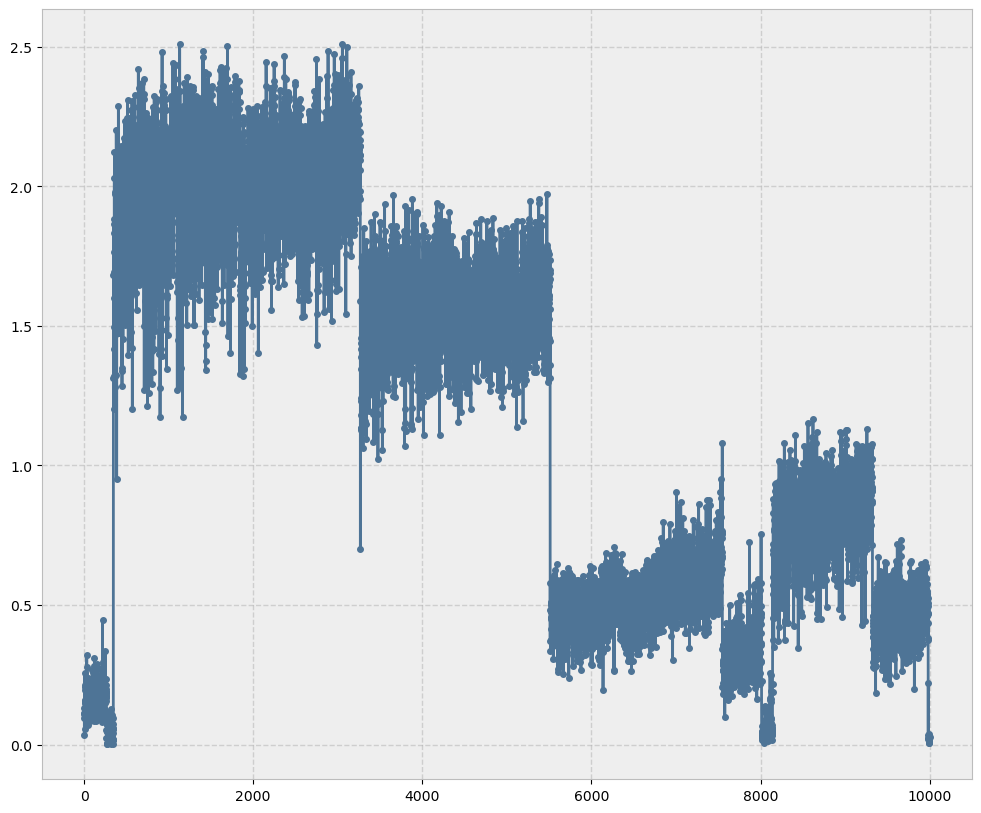

In [133]:
plt.plot(y_max.detach().cpu().numpy()**2)

### Улучшенные как бэ сэмплер.

In [16]:
def sample_gibbs(
    model,
    n_samples: int = 100,
    burn_in: int = 2000,
    thin: int = 10,
    epsilon: float = 1e-8
) -> np.ndarray:
    """
    Gibbs sampler for p(x) ∝ f(x)^2.
    Updates each coordinate sequentially from its full conditional.
    """
    device = next(model.parameters()).device
    n_features = model.n_features
    
    x = torch.randint(0, 2, (n_features,), dtype=torch.float32, device=device)
    
    def conditional_prob(idx):
        x0 = x.clone()
        x1 = x.clone()
        x0[idx] = 0
        x1[idx] = 1
        with torch.no_grad():
            f0 = model(x0.unsqueeze(0)).item()
            f1 = model(x1.unsqueeze(0)).item()
        p1 = (f1*f1) / (f0*f0 + f1*f1 + epsilon)
        return p1
    
    # Burn-in
    for _ in range(burn_in):
        for idx in range(n_features):
            p = conditional_prob(idx)
            x[idx] = 1 if np.random.rand() < p else 0
    
    samples = []
    for _ in range(n_samples):
        for _ in range(thin):
            for idx in range(n_features):
                p = conditional_prob(idx)
                x[idx] = 1 if np.random.rand() < p else 0
        samples.append(x.cpu().numpy().copy())
    
    return np.array(samples)

In [17]:
samples = sample_gibbs(model, n_samples=500, burn_in=5000, thin=10)
f2_values = evaluate_samples(model, samples)  # ваша функция
print("Mean f²:", f2_values.mean())
print("Max f²:", f2_values.max())

Mean f²: 1.1873614
Max f²: 2.6117718


# Отедельно 2-частичное взаимодействие, не исопользуем

In [ ]:
class ANOVAKernel(nn.Module):
    """Second-order ANOVA kernel (Factorization Machine) for binary features."""
    def __init__(self, n_features: int, k: int = 10):
        super().__init__()
        self.n_features = n_features
        self.k = k
        self.w0 = nn.Parameter(torch.zeros(1))
        self.w = nn.Parameter(torch.zeros(n_features))
        self.V = nn.Parameter(torch.randn(n_features, k) * 0.01)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, n_features)
        linear = self.w0 + torch.matmul(x, self.w)           # (batch,)

        sum_vx = torch.matmul(x, self.V)                     # (batch, k)
        sum_sq = torch.sum(sum_vx ** 2, dim=1)               # (batch,)

        sq_sum = torch.sum(torch.matmul(x, self.V ** 2), dim=1)  # (batch,)

        interaction = 0.5 * (sum_sq - sq_sum)                # (batch,)
        return linear + interaction

    def log_prob(self, x: torch.Tensor, epsilon: float = 1e-8) -> torch.Tensor:
        """Unnormalised log-probability proportional to f(x)^2."""
        f = self.forward(x)
        return 2 * torch.log(torch.abs(f) + epsilon)


def fit_anova_kernel(
    X: np.ndarray,          # binary features, shape (n_samples, n_features)
    y: np.ndarray,          # target values (regression)
    d: int = 2,             # order (only 2 is implemented)
    k: int = 10,            # number of factors
    lr: float = 0.01,
    epochs: int = 100,
    reg: float = 0.01,
    batch_size: int = 256,
    verbose: bool = True
) -> ANOVAKernel:
    """Train a second-order ANOVA kernel (FM) on binary data."""
    if d != 2:
        raise NotImplementedError("Only order 2 is implemented in this example.")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    y_t = torch.tensor(y, dtype=torch.float32).view(-1, 1).to(device)

    model = ANOVAKernel(n_features=X.shape[1], k=k).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    dataset = torch.utils.data.TensorDataset(X_t, y_t)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        total_loss = 0.0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            pred = model(batch_x).view(-1, 1)
            loss = criterion(pred, batch_y)
            reg_loss = reg * (model.w0**2 + model.w.norm(2)**2 + model.V.norm(2)**2)
            (loss + reg_loss).backward()
            optimizer.step()
            total_loss += loss.item() * batch_x.size(0)
        if verbose and (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(X):.4f}")

    return model


def sample(
    model: ANOVAKernel,
    n_samples: int = 100,
    burn_in: int = 1000,
    steps_per_sample: int = 10,
    epsilon: float = 1e-8
) -> np.ndarray:
    """
    Sample binary vectors from p(x) ∝ f(x)^2 using Metropolis-Hastings.
    Proposal: flip one randomly chosen bit.
    """
    device = next(model.parameters()).device
    n_features = model.n_features

    # start from random binary vector
    x = torch.randint(0, 2, (n_features,), dtype=torch.float32, device=device)
    current_logp = model.log_prob(x.unsqueeze(0), epsilon=epsilon).item()

    samples = []

    # burn-in
    for _ in range(burn_in):
        idx = torch.randint(0, n_features, (1,)).item()
        x_prop = x.clone()
        x_prop[idx] = 1 - x_prop[idx]
        prop_logp = model.log_prob(x_prop.unsqueeze(0), epsilon=epsilon).item()
        if np.log(np.random.rand()) < prop_logp - current_logp:
            x = x_prop
            current_logp = prop_logp

    # sampling
    for _ in range(n_samples):
        for _ in range(steps_per_sample):
            idx = torch.randint(0, n_features, (1,)).item()
            x_prop = x.clone()
            x_prop[idx] = 1 - x_prop[idx]
            prop_logp = model.log_prob(x_prop.unsqueeze(0), epsilon=epsilon).item()
            if np.log(np.random.rand()) < prop_logp - current_logp:
                x = x_prop
                current_logp = prop_logp
        samples.append(x.cpu().numpy().copy())

    return np.array(samples)


# Example usage
if __name__ == "__main__":
    np.random.seed(42)
    n, p = 1000, 20
    X = np.random.randint(0, 2, size=(n, p))
    true_weights = np.random.randn(p)
    true_inter = np.random.randn(p, p) * 0.1
    y = (X @ true_weights) + np.sum(X @ true_inter * X, axis=1) + 0.1 * np.random.randn(n)

    model = fit_anova_kernel(X, y, k=10, epochs=500, lr=0.01, reg=0.001)
    samples = sample(model, n_samples=1000, burn_in=500, steps_per_sample=5)

    print(f"Generated {len(samples)} samples of dimension {samples.shape[1]}")
    print("Sample mean (first 5 features):", samples.mean(axis=0)[:5])
    print("Original data mean (first 5 features):", X.mean(axis=0)[:5])